# From DICOM to a Trained Model — CT Imaging AI

## Part A - Recap: One Real CT Scan

### Step 1 - Install & Import

In [ ]:
!pip install -q pydicom

import numpy as np
import matplotlib.pyplot as plt
import pydicom
from pydicom.data import get_testdata_file

print("pydicom version:", pydicom.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 17.4 MB/s eta 0:00:00
pydicom version: 3.0.2


### Step 2 - Get a Real DICOM CT File

In [ ]:
path = get_testdata_file("CT_small.dcm")
dcm = pydicom.dcmread(path)

print("Modality:      ", dcm.Modality)
print("Rows x Columns:", dcm.Rows, "x", dcm.Columns)
print("Pixel Spacing: ", dcm.PixelSpacing if "PixelSpacing" in dcm else "not set")
print("Rescale Slope: ", dcm.get("RescaleSlope", 1))
print("Rescale Intercept:", dcm.get("RescaleIntercept", 0))

raw_pixels = dcm.pixel_array
print("\nRaw pixel array shape:", raw_pixels.shape)
print("Raw pixel value range:", raw_pixels.min(), "to", raw_pixels.max())


Modality:       CT
Rows x Columns: 128 x 128
Pixel Spacing:  [0.661468, 0.661468]
Rescale Slope:  1
Rescale Intercept: -1024

Raw pixel array shape: (128, 128)
Raw pixel value range: 128 to 2191


### Step 3 - Convert to Hounsfield Units (HU)

Raw CT pixel values aren't directly meaningful,, they need to be converted using the scan's own `RescaleSlope` and `RescaleIntercept` into **Hounsfield Units**, the standard scale for tissue density (air ≈ -1000, water = 0, bone ≈ +1000).

HU value range: -896.0 to 1167.0


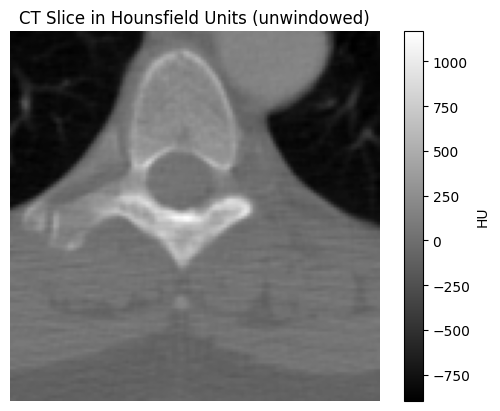

In [ ]:
def to_hounsfield_units(dcm_file):
    pixels = dcm_file.pixel_array.astype(np.int16)
    slope = float(dcm_file.get("RescaleSlope", 1))
    intercept = float(dcm_file.get("RescaleIntercept", 0))
    hu = pixels * slope + intercept
    return hu

hu_image = to_hounsfield_units(dcm)
print("HU value range:", hu_image.min(), "to", hu_image.max())

plt.imshow(hu_image, cmap="gray")
plt.title("CT Slice in Hounsfield Units (unwindowed)")
plt.colorbar(label="HU")
plt.axis("off")
plt.show()


| Tissue      | HU           |
| ----------- | ------------ |
| Air         | -1000        |
| Lung        | -700 to -500 |
| Fat         | -120 to -50  |
| Water       | 0            |
| Soft Tissue | 30 to 80     |
| Bone        | 300 to 3000+ |


### Step 4 - Apply Windowing

A CT scan's full HU range is too wide to see everything at once. **Windowing** clips the range to focus on one tissue type e.g., a "soft tissue window" or "bone window" exactly what a radiologist adjusts when reading a scan.

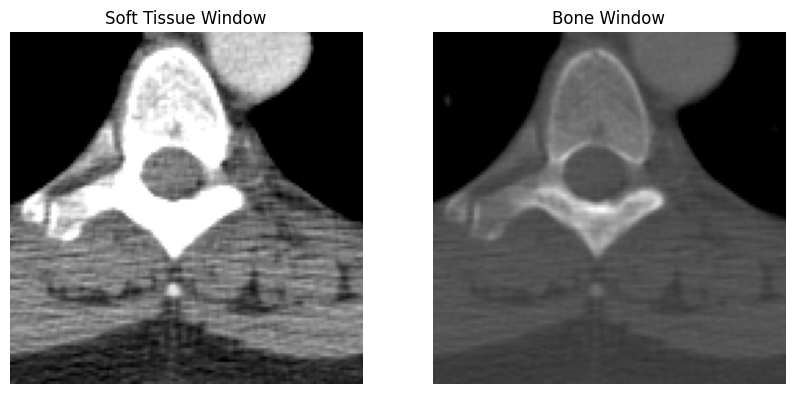

In [ ]:
def apply_window(hu_image, center, width):
    low = center - width // 2
    high = center + width // 2
    windowed = np.clip(hu_image, low, high)
    normalized = (windowed - low) / (high - low)   # scale to [0, 1]
    return normalized

# Common presets
soft_tissue = apply_window(hu_image, center=40,  width=400)
bone_window = apply_window(hu_image, center=400, width=1800)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(soft_tissue, cmap="gray")
axes[0].set_title("Soft Tissue Window")
axes[0].axis("off")

axes[1].imshow(bone_window, cmap="gray")
axes[1].set_title("Bone Window")
axes[1].axis("off")
plt.show()


Why Is Windowing Important for Machine Learning?

#For ML and deep learning:

Removes irrelevant HU values.
Enhances important anatomical structures.
Reduces noise.
Standardizes inputs across scans.

####DICOM File
    ↓
####Read Metadata
    ↓
####Extract Pixel Array
    ↓
####Convert to Hounsfield Units
    ↓
####Check HU Range
    ↓
####Display CT Slice
    ↓
####Windowing / Normalization
    ↓
####Feature Extraction or Deep Learning

### Step 5 - Resize (ML-Ready Shape)

Resized shape: (64, 64)
Value range:   0.0 to 1.0


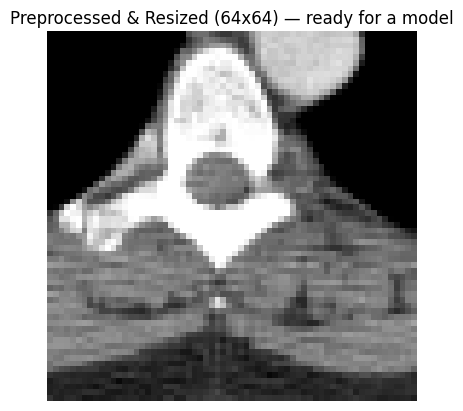

In [ ]:
import cv2

resized = cv2.resize(soft_tissue.astype("float32"), (64, 64), interpolation=cv2.INTER_AREA)
print("Resized shape:", resized.shape)
print("Value range:  ", resized.min(), "to", resized.max())

plt.imshow(resized, cmap="gray")
plt.title("Preprocessed & Resized (64x64) — ready for a model")
plt.axis("off")
plt.show()


 `resized` is a single, fully preprocessed CT slice — normalized, windowed, resized.

---


## Part B - Scaling Up to a Trainable Dataset

### Why one scan isn't enough

A model can't learn anything meaningful from a single image. Real CT-based AI models are trained on **hundreds or thousands of labeled scans from many different patients** which is exactly why hospitals and research groups spend so much effort curating labeled imaging datasets.

For this notebook, we'll use **OrganCMNIST**  a dataset built from **real, de-identified CT scans**, where each image is a 2D coronal slice labeled by which abdominal organ it shows (liver, kidney, spleen, etc.). It's been through the same kind of preprocessing pipeline you just did by hand in Part A — windowed, normalized and resized — just already done at scale across many patients.

In [ ]:
!pip install -q medmnist

import medmnist
from medmnist import OrganCMNIST

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("medmnist version:", medmnist.__version__)
print("TensorFlow version:", tf.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.2 MB/s eta 0:00:00
medmnist version: 3.0.2
TensorFlow version: 2.20.0


| Label | Organ   |
| ----- | ------- |
| 0     | Spleen  |
| 1     | Kidney  |
| 2     | Liver   |
| 3     | Stomach |
| ...   | ...     |


#TensorFlow is Google's deep learning framework.

It provides tools to build:

Neural Networks
CNNs
RNNs
Transformers

For CT image classification, mostly CNNs is used.

### Step 6 — Download the Dataset


In [ ]:
train_dataset = OrganCMNIST(split="train", download=True, size=64)
val_dataset   = OrganCMNIST(split="val",   download=True, size=64)
test_dataset  = OrganCMNIST(split="test",  download=True, size=64)

print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))
print("Test samples: ", len(test_dataset))

organ_names = {
    0: "bladder", 1: "femur-left", 2: "femur-right", 3: "heart",
    4: "kidney-left", 5: "kidney-right", 6: "liver", 7: "lung-left",
    8: "lung-right", 9: "pancreas", 10: "spleen"
}


100%|██████████| 80.3M/80.3M [01:05<00:00, 1.23MB/s]


Train samples: 12975
Val samples:   2392
Test samples:  8216


                 OrganCMNIST
                 20,000 images
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
       TRAIN          VAL          TEST
       70%            10%           20%
          │            │             │
          ↓            ↓             ↓
       LEARN        CHECK          FINAL
       MODEL        MODEL          EXAM

X_train shape: (12975, 64, 64)
Number of organ classes: 11
Class distribution (train): [1148  619  595  600 1088 1170 2986 1002 1022 1173 1572]


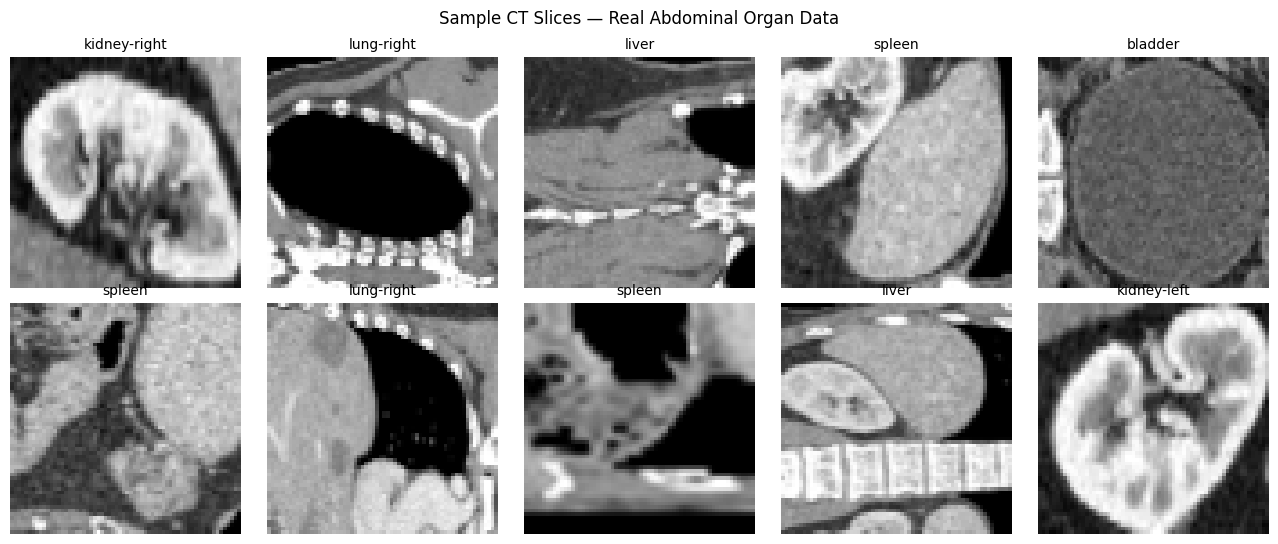

In [ ]:
X_train, y_train = train_dataset.imgs, train_dataset.labels.flatten()
X_val,   y_val   = val_dataset.imgs,   val_dataset.labels.flatten()
X_test,  y_test  = test_dataset.imgs,  test_dataset.labels.flatten()

print("X_train shape:", X_train.shape)
print("Number of organ classes:", len(organ_names))
print("Class distribution (train):", np.bincount(y_train))

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(organ_names[y_train[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample CT Slices — Real Abdominal Organ Data")
plt.tight_layout()
plt.show()


### Step 7 — Preprocess

Normalize to `[0, 1]` and add the channel dimension.
Why normalize? Neural networks generally train more efficiently when input values are on a relatively small, consistent scale.

In [ ]:
def preprocess(images, labels):
    images = images.astype("float32") / 255.0
    images = np.expand_dims(images, axis=-1)
    return images, labels

X_train_p, y_train_p = preprocess(X_train, y_train)
X_val_p,   y_val_p   = preprocess(X_val,   y_val)
X_test_p,  y_test_p  = preprocess(X_test,  y_test)

print("Preprocessed shape:", X_train_p.shape)


Preprocessed shape: (12975, 64, 64, 1)


                OrganCMNIST
                     ↓
              64 × 64 images
                     ↓
          ┌────────────────────┐
          │     preprocess()   │
          └────────────────────┘
                     ↓
              float32
                     ↓
              divide by 255
                     ↓
                0 → 1
                     ↓
            Add channel = 1
                     ↓
              64 × 64 × 1
                     ↓
              TensorFlow CNN

### Step 8 — Build a CNN



In [ ]:
num_classes = len(organ_names)

model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,987 (1.55 MB)

 Trainable params: 406,987 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

RAW IMAGE
64 × 64 × 1
      ↓
   Conv2D
Find simple patterns
      ↓
  MaxPooling
Reduce size
      ↓
   Conv2D
Find more complex patterns
      ↓
  MaxPooling
Reduce size
      ↓
   Flatten
Turn features into vector
      ↓
    Dense
Combine features
      ↓
   Dropout
Reduce overfitting
      ↓
   Dense + Softmax
      ↓
11 probabilities
      ↓
"Liver"

              CT IMAGE
            64 × 64 × 1
                  ↓
        ┌─────────────────┐
        │  Conv + Pool    │ ← Extract features
        │  Conv + Pool    │
        └─────────────────┘
                  ↓
               Flatten
                  ↓
             Dense 64
                  ↓
              Dropout
                  ↓
           Dense 11 + Softmax
                  ↓
        ┌───────────────────┐
        │ 11 probabilities  │
        └───────────────────┘
                  ↓
            "Liver"

### Step 9 — Train

In [ ]:
history = model.fit(
    X_train_p, y_train_p,
    validation_data=(X_val_p, y_val_p),
    epochs=8,
    batch_size=32
)


Epoch 1/8
406/406 ━━━━━━━━━━━━━━━━━━━━ 58s 137ms/step - accuracy: 0.5832 - loss: 1.2051 - val_accuracy: 0.9130 - val_loss: 0.3768
Epoch 2/8
406/406 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.8058 - loss: 0.5829 - val_accuracy: 0.9590 - val_loss: 0.1798
Epoch 3/8
406/406 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.8504 - loss: 0.4377 - val_accuracy: 0.9561 - val_loss: 0.1894
Epoch 4/8
406/406 ━━━━━━━━━━━━━━━━━━━━ 39s 96ms/step - accuracy: 0.8722 - loss: 0.3711 - val_accuracy: 0.9419 - val_loss: 0.2192
Epoch 5/8
406/406 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.8883 - loss: 0.3251 - val_accuracy: 0.9540 - val_loss: 0.1837
Epoch 6/8
406/406 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.9037 - loss: 0.2758 - val_accuracy: 0.9528 - val_loss: 0.1742
Epoch 7/8
406/406 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.9151 - loss: 0.2450 - val_accuracy: 0.9515 - val_loss: 0.1844
Epoch 8/8
406/406 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9200 - loss: 0.2225 - val_ac

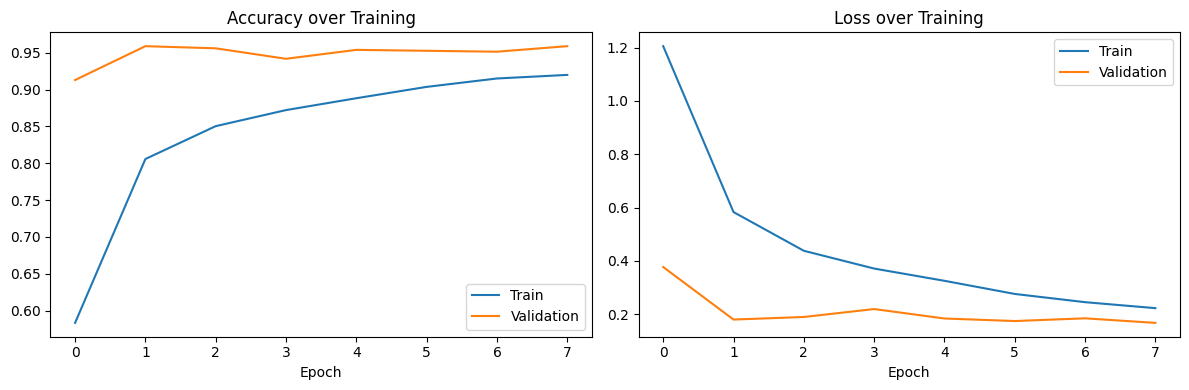

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy over Training")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss over Training")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


### Step 10 — Evaluate on the Test Set

Test accuracy: 0.871
              precision    recall  f1-score   support

     bladder       0.84      0.82      0.83       828
  femur-left       0.68      0.90      0.77       431
 femur-right       0.82      0.78      0.80       421
       heart       0.99      0.89      0.93       421
 kidney-left       0.79      0.65      0.71       727
kidney-right       0.81      0.66      0.73       735
       liver       0.97      0.97      0.97      1835
   lung-left       0.94      0.92      0.93       549
  lung-right       0.94      0.98      0.96       557
    pancreas       0.85      0.93      0.89       750
      spleen       0.83      0.93      0.88       962

    accuracy                           0.87      8216
   macro avg       0.86      0.86      0.85      8216
weighted avg       0.87      0.87      0.87      8216



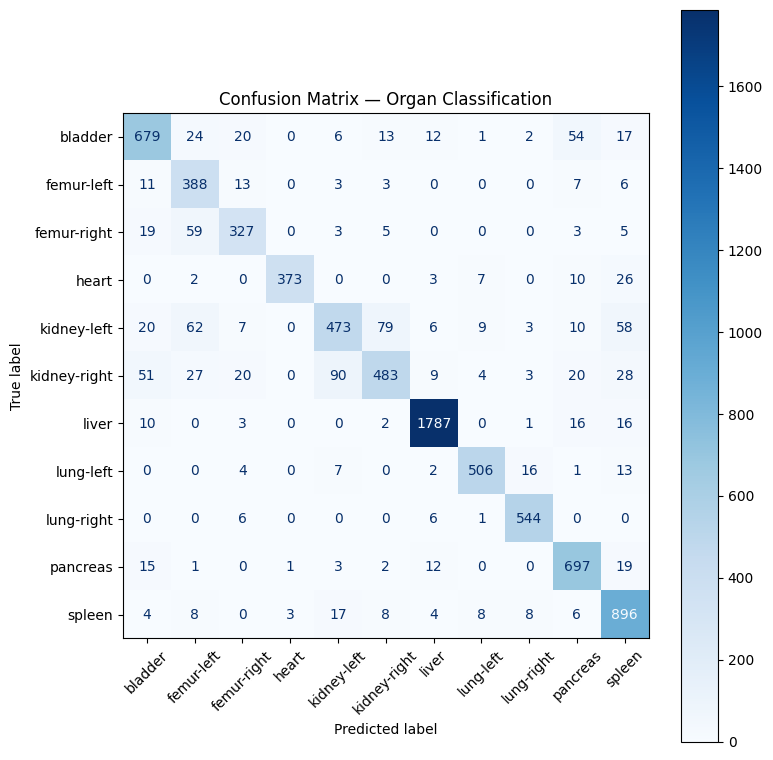

In [ ]:
test_loss, test_acc = model.evaluate(X_test_p, y_test_p, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

y_pred_prob = model.predict(X_test_p, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test_p, y_pred,
    target_names=[organ_names[i] for i in range(num_classes)]
))

cm = confusion_matrix(y_test_p, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(organ_names.values()))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Organ Classification")
plt.tight_layout()
plt.show()


### Step 11 — Predict on a Single CT Slice

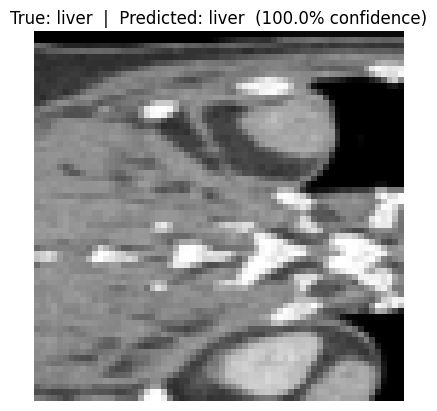

In [ ]:
idx = 12   # try changing this index

sample_img = X_test_p[idx]
true_label = int(y_test_p[idx])

pred_prob = model.predict(sample_img[np.newaxis, ...], verbose=0)[0]
pred_label = int(np.argmax(pred_prob))
confidence = pred_prob[pred_label]

plt.imshow(sample_img.squeeze(), cmap="gray")
plt.title(
    f"True: {organ_names[true_label]}  |  "
    f"Predicted: {organ_names[pred_label]}  ({confidence:.1%} confidence)"
)
plt.axis("off")
plt.show()


In [2]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.9 MB/s eta 0:00:00


In [3]:
from medmnist import INFO

print(f"{'Dataset':16s} {'Task':16s} {'Classes':8s} {'Channels':9s} {'Total Samples':14s}")
print('-' * 70)
for key, info in INFO.items():
    n_classes = len(info.get('label', {}))
    channels = info.get('n_channels')
    total = sum(info.get('n_samples', {}).values())
    task = info.get('task', '')
    print(f'{key:16s} {task:16s} {n_classes:<8d} {channels:<9d} {total:<14d}')

Dataset          Task             Classes  Channels  Total Samples 
----------------------------------------------------------------------
pathmnist        multi-class      9        3         107180        
chestmnist       multi-label, binary-class 14       1         112120        
dermamnist       multi-class      7        3         10015         
octmnist         multi-class      4        1         109309        
pneumoniamnist   binary-class     2        1         5856          
retinamnist      ordinal-regression 5        3         1600          
breastmnist      binary-class     2        1         780           
bloodmnist       multi-class      8        3         17092         
tissuemnist      multi-class      8        1         236386        
organamnist      multi-class      11       1         58830         
organcmnist      multi-class      11       1         23583         
organsmnist      multi-class      11       1         25211         
organmnist3d     multi-class      

In [4]:
print(INFO['organcmnist']['description'])

The OrganCMNIST is based on 3D computed tomography (CT) images from Liver Tumor Segmentation Benchmark (LiTS). It is renamed from OrganMNIST_Coronal (in MedMNIST v1) for simplicity. We use bounding-box annotations of 11 body organs from another study to obtain the organ labels. Hounsfield-Unit (HU) of the 3D images are transformed into gray-scale with an abdominal window. We crop 2D images from the center slices of the 3D bounding boxes in coronal views (planes). The images are resized into 1×28×28 to perform multi-class classification of 11 body organs. 115 and 16 CT scans from the source training set are used as training and validation set, respectively. The 70 CT scans from the source test set are treated as the test set.


| Medical data       | Typical AI task                                  | Possible model           |
| ------------------ | ------------------------------------------------ | ------------------------ |
| **CT**             | Organ classification, tumor detection            | CNN / ResNet / 3D CNN    |
| **MRI**            | Brain tumor detection, tissue classification     | CNN / 3D CNN             |
| **X-ray**          | Pneumonia, fracture detection                    | CNN / ResNet             |
| **Ultrasound**     | Breast lesion classification, fetal measurements | CNN / Vision Transformer |
| **Histopathology** | Cancer/tissue classification                     | CNN / Vision Transformer |
| **Dermatoscopy**   | Skin-lesion classification                       | CNN / Vision Transformer |


###Ct scan
DICOM
 ↓
Pixel values
 ↓
Hounsfield Units (HU)
 ↓
Windowing
 ↓
Normalization
 ↓
Resize
 ↓
CNN

###Ultrasound
Ultrasound image
       ↓
Remove unnecessary borders/text if needed
       ↓
Resize
       ↓
Normalize pixel intensities
       ↓
Augmentation
       ↓
CNN
       ↓
Disease/organ prediction

###MRI
MRI
 ↓
Bias-field correction
 ↓
Registration
 ↓
Intensity normalization
 ↓
Resize/resample
 ↓
CNN

###Non-Medical imaging data
Patient data
(age, glucose, BP, etc.)
       ↓
Cleaning
       ↓
Missing-value handling
       ↓
Encoding
       ↓
Scaling
       ↓
ML model
       ↓
Disease prediction

Medical AI takes raw medical data → preprocesses it appropriately → extracts patterns using a model → predicts something clinically meaningful → evaluates the predictions.